## COMERCIO

Import dos dados

In [1]:
from google.colab import files
uploaded = files.upload()

Import da biblioteca pandas, e leitura do csv.
(Utilizei sep=' ; ', pois a importação não estava funcionando sem).
Por fim visualização do cabeçalho

In [2]:
import pandas as pd

df_comercio = pd.read_csv('Comercio.csv', sep=';')
df_comercio.head()

,id,control,Produto,1970,1971,1972,1973,1974,1975,1976,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,1,VINHO DE MESA,VINHO DE MESA,98327606,114399031,118377367,116617910,94173324,108031792,139238614,...,206404427,209198468,166769622,176059959,177186273,180446489,215557931,210012238,187939996,187016848
1,2,vm_Tinto,Tinto,83300735,98522869,101167932,98196747,77167303,91528090,116407222,...,178250072,182028785,146646365,154309442,155115499,158519218,189573423,185653678,165067340,165097539
2,3,vm_Rosado,Rosado,107681,542274,7770851,8425617,8891367,7261777,11748047,...,1419855,1409002,1391942,1097426,1972944,1265435,1394901,1931606,2213723,2520748
3,4,vm_Branco,Branco,14919190,15333888,9438584,9995546,8114654,9241925,11083345,...,26734500,25760681,18731315,20653091,20097830,20661836,24589607,22426954,20658933,19398561
4,5,VINHO FINO DE MESA,VINHO FINO DE MESA,4430629,4840369,5602091,7202830,7571802,8848303,14095648,...,20424983,20141631,19630158,15874354,14826143,15684588,24310834,27080445,21533487,18589310


Renomeando a coluna control para tipo, para facilitar a leitura.

In [3]:
df_comercio = df_comercio.rename(columns={'control': 'Tipo'})

O Melt é para colocar a formatação da tabela em "long" (antes estava no formato "wide") com a intenção de facilitar a visualização dos dados. Em seguida eu declaro meu DataFrame. Id_Vars eu declaro as colunas que não serão transformadas. Na parte `var_name='Ano'` As colunas de anos (1970 até 2023) virarão valores nesta nova coluna chamada Ano. `value_name='Quantidade (L)'`	Os valores (quantidade de litros) que estavam nas colunas de anos agora vão para essa coluna.

In [4]:
df_comerciopivot = pd.melt(
    df_comercio,
    id_vars=['id', 'Tipo', 'Produto'],
    var_name='Ano',
    value_name='Quantidade (L)'
)

Convertendo para inteiro, para facilitar gráficos e etc.

In [5]:
df_comerciopivot['Ano'] = df_comerciopivot['Ano'].astype(int)

Ordenando por ID e Ano

In [6]:
df_comerciopivot = df_comerciopivot.sort_values(by=['id', 'Ano']).reset_index(drop=True)


Visualização do cebeçalho

In [7]:
df_comerciopivot.head()


,id,Tipo,Produto,Ano,Quantidade (L)
0,1,VINHO DE MESA,VINHO DE MESA,1970,98327606
1,1,VINHO DE MESA,VINHO DE MESA,1971,114399031
2,1,VINHO DE MESA,VINHO DE MESA,1972,118377367
3,1,VINHO DE MESA,VINHO DE MESA,1973,116617910
4,1,VINHO DE MESA,VINHO DE MESA,1974,94173324


In [8]:
# df_comerciopivot.to_csv('ComercioPivot.csv', index=False)

## PRODUÇÃO

In [9]:
from google.colab import files
uploaded = files.upload()

In [10]:
df_producao = pd.read_csv('Producao.csv', sep=';')
df_producao.head()

,id,control,produto,1970,1971,1972,1973,1974,1975,1976,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,1,VINHO DE MESA,VINHO DE MESA,217208604,154264651,146953297,116710345,193875345,177401209,144565438,...,196173123,210308560,86319015,255015187,218375636,144629737,124200414,173899995,195031611,169762429
1,2,vm_Tinto,Tinto,174224052,121133369,118180926,88589019,146544484,144274134,118360170,...,157776363,169811472,75279191,1365957,188270142,121045115,103916391,146075996,162844214,139320884
2,3,vm_Branco,Branco,748400,1160500,1812367,243900,4138768,1441507,1871473,...,37438069,39557250,10727099,217527985,29229970,22032828,19568734,26432799,30198430,27910299
3,4,vm_Rosado,Rosado,42236152,31970782,26960004,27877426,43192093,31685568,24333795,...,958691,939838,312725,36121245,875524,1551794,715289,1391200,1988968,2531246
4,5,VINHO FINO DE MESA (VINIFERA),VINHO FINO DE MESA (VINIFERA),23899346,23586062,21078771,12368410,31644124,39424590,34500590,...,38464314,37148982,18070626,44537870,38707220,37615422,32516686,43474998,47511796,46268556


In [11]:
df_producao = df_producao.rename(columns={'control': 'Tipo'})
df_producao = df_producao.rename(columns={'produto': 'Produto'})

In [12]:
df_producaopivot = pd.melt(
    df_producao,
    id_vars=['id', 'Tipo', 'Produto'],
    var_name='Ano',
    value_name='Quantidade (L)'
)

In [13]:
df_producaopivot['Ano'] = df_producaopivot['Ano'].astype(int)

In [14]:
df_producaopivot = df_producaopivot.sort_values(by=['id', 'Ano']).reset_index(drop=True)

In [15]:
df_producaopivot.head()

,id,Tipo,Produto,Ano,Quantidade (L)
0,1,VINHO DE MESA,VINHO DE MESA,1970,217208604
1,1,VINHO DE MESA,VINHO DE MESA,1971,154264651
2,1,VINHO DE MESA,VINHO DE MESA,1972,146953297
3,1,VINHO DE MESA,VINHO DE MESA,1973,116710345
4,1,VINHO DE MESA,VINHO DE MESA,1974,193875345


In [16]:
# df_producaopivot.to_csv('ProducaoPivot.csv', index=False)

#Gráficos

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

sns.set(style='whitegrid', palette='muted')

## Evolução da produção por produto ao longo dos anos

/tmp/ipython-input-18-1504172595.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


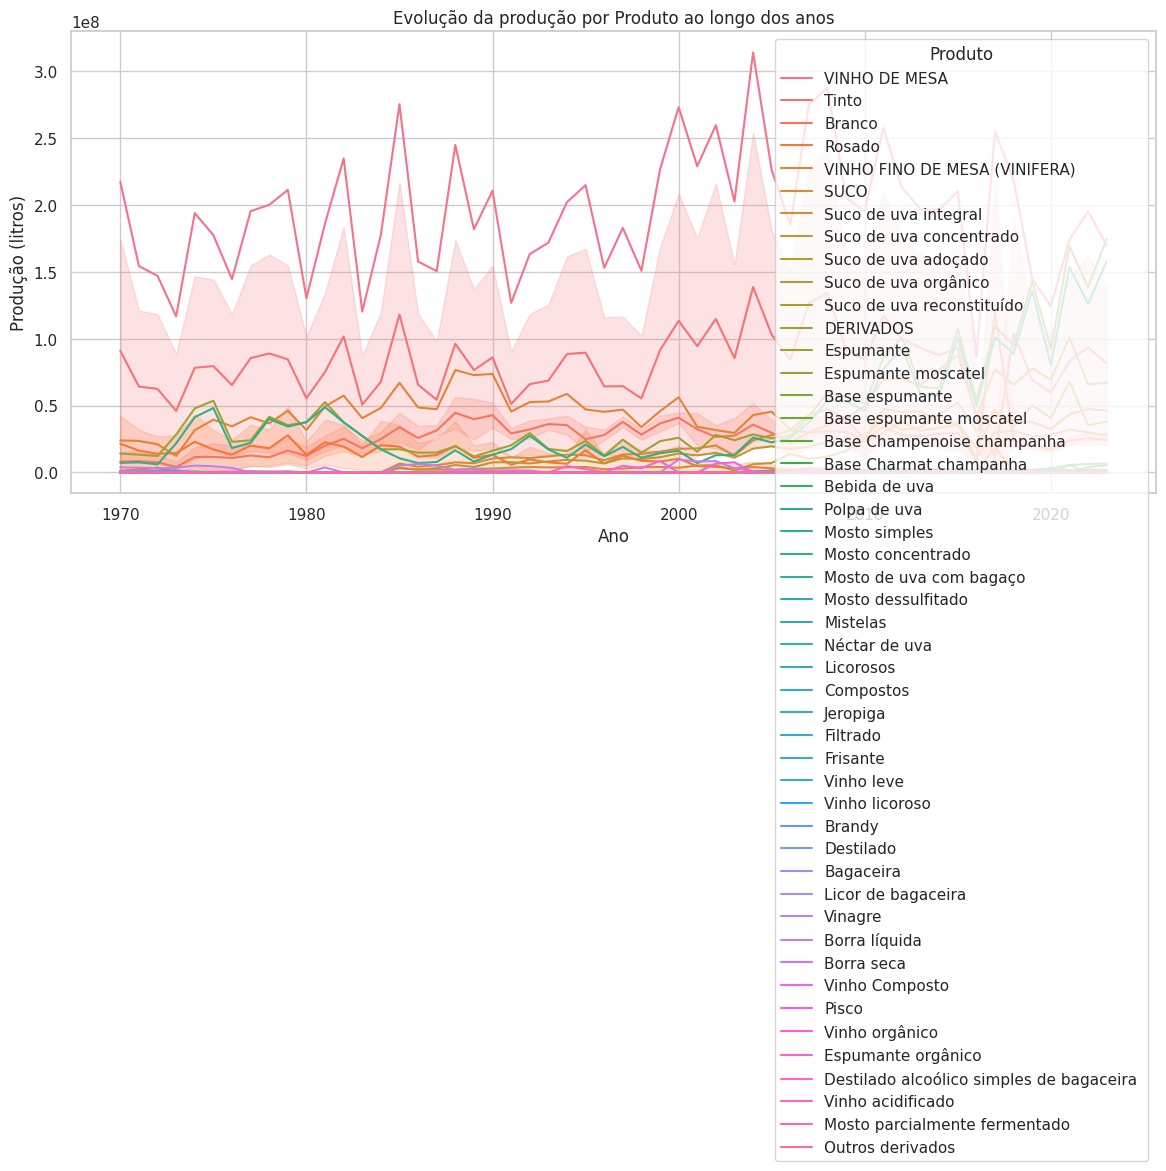

In [18]:
plt.figure(figsize=(14, 6))
sns.lineplot(
    data=df_producaopivot,
    x='Ano',
    y='Quantidade (L)',
    hue='Produto'
)
plt.title('Evolução da produção por Produto ao longo dos anos')
plt.ylabel('Produção (litros)')
plt.xlabel('Ano')
plt.legend(title='Produto')
plt.tight_layout()
plt.show()

# Comparar tipos (ex: Tinto, Branco) por ano

/tmp/ipython-input-19-2020062980.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


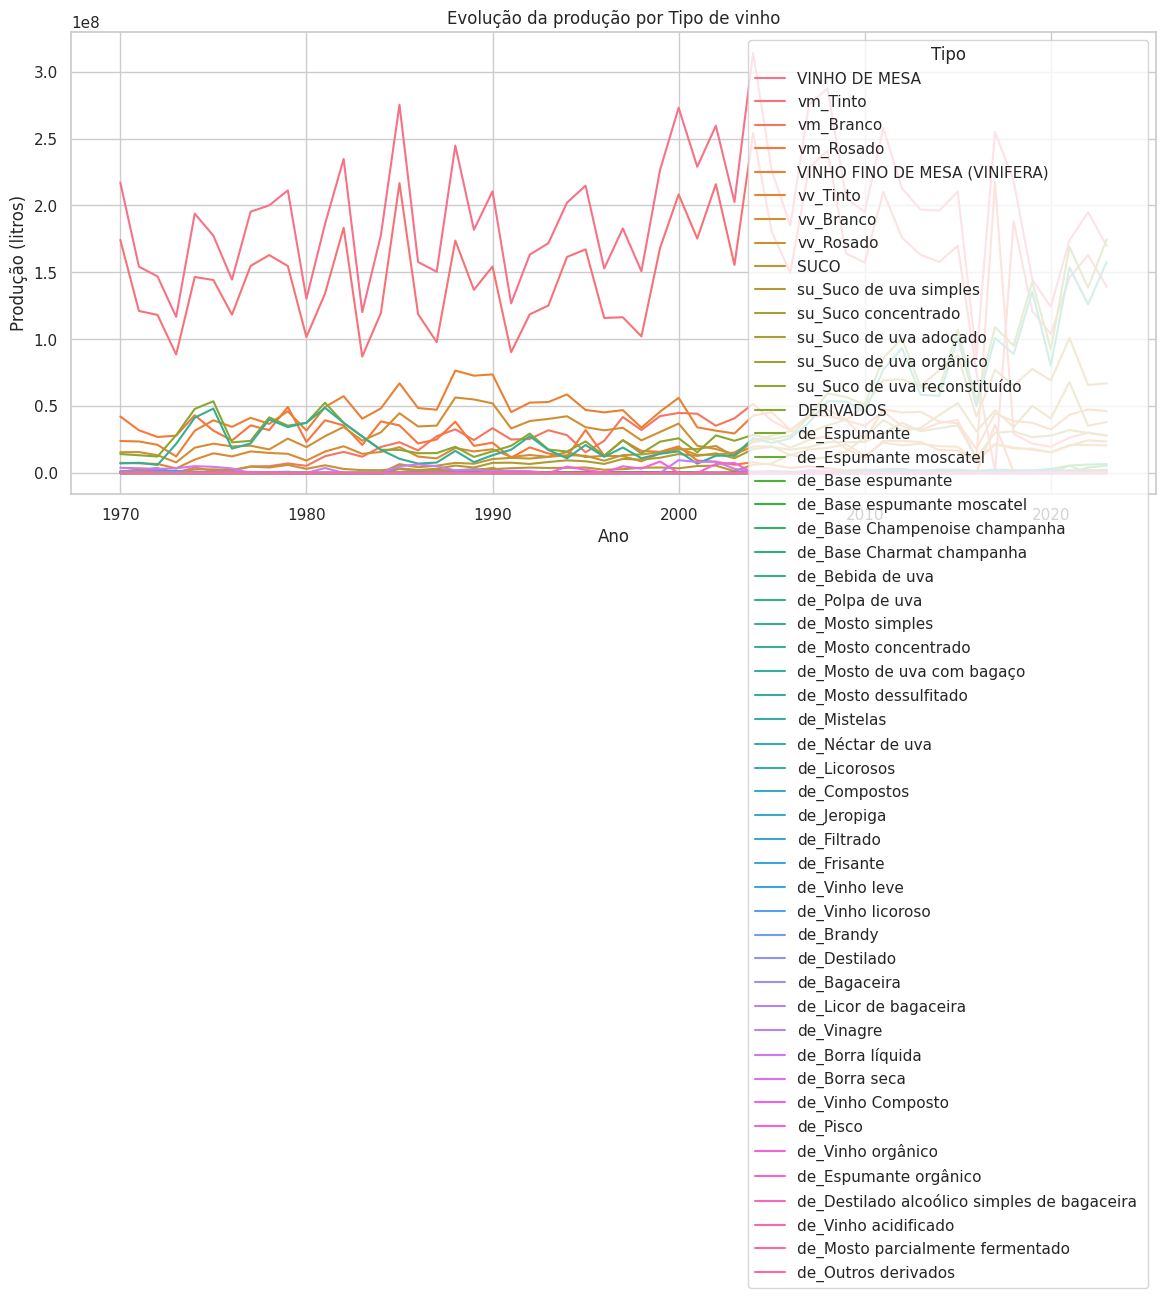

In [19]:
plt.figure(figsize=(14, 6))
sns.lineplot(
    data=df_producaopivot,
    x='Ano',
    y='Quantidade (L)',
    hue='Tipo'
)
plt.title('Evolução da produção por Tipo de vinho')
plt.ylabel('Produção (litros)')
plt.xlabel('Ano')
plt.legend(title='Tipo')
plt.tight_layout()
plt.show()

## Top produtos por produção total (Top 5)

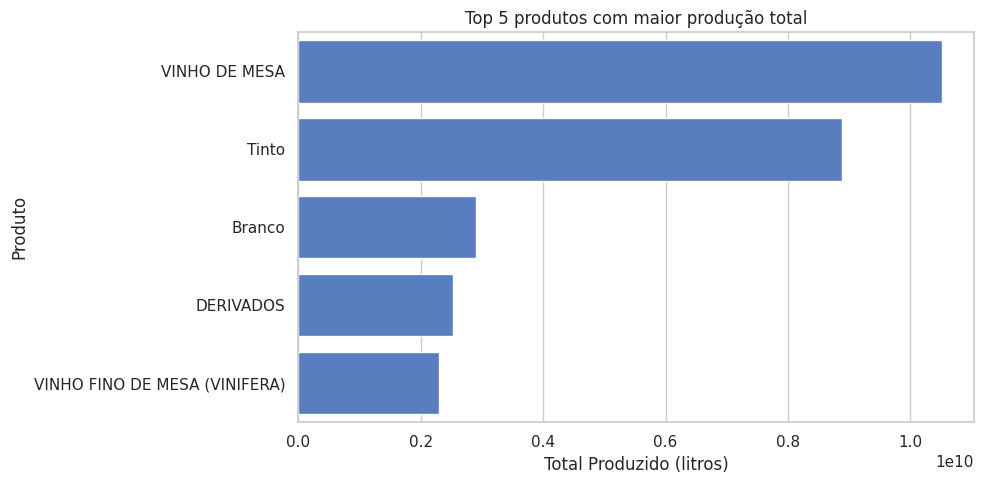

In [20]:
top_produtos = (
    df_producaopivot.groupby('Produto')['Quantidade (L)']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=top_produtos.values,
    y=top_produtos.index
)
plt.title('Top 5 produtos com maior produção total')
plt.xlabel('Total Produzido (litros)')
plt.ylabel('Produto')
plt.tight_layout()
plt.show()

## Comparação entre produção e comércio para um produto específico


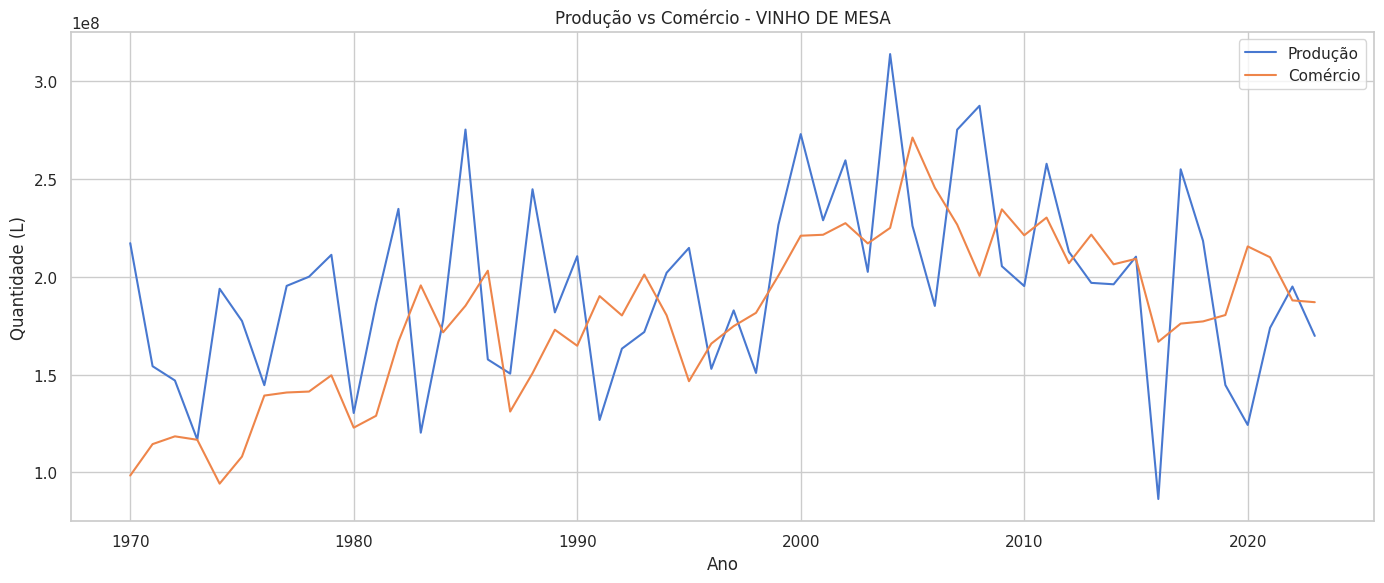

In [21]:
produto_filtro = 'VINHO DE MESA'

df_produto_comercial = df_comerciopivot[df_comerciopivot['Produto'] == produto_filtro]
df_produto_producao = df_producaopivot[df_producaopivot['Produto'] == produto_filtro]

plt.figure(figsize=(14, 6))
plt.plot(df_produto_producao['Ano'], df_produto_producao['Quantidade (L)'], label='Produção')
plt.plot(df_produto_comercial['Ano'], df_produto_comercial['Quantidade (L)'], label='Comércio')
plt.title(f'Produção vs Comércio - {produto_filtro}')
plt.xlabel('Ano')
plt.ylabel('Quantidade (L)')
plt.legend()
plt.tight_layout()
plt.show()

## Testando gráfico interativo de linha com % de crescimento por Produto

In [23]:
# Cálculo do crescimento percentual por produto
df_growth = df_producaopivot.sort_values(by=['Produto', 'Ano']).copy()
df_growth['Crescimento (%)'] = df_growth.groupby('Produto')['Quantidade (L)'].pct_change() * 100

# Remove primeiros anos que não têm comparação
df_growth = df_growth.dropna(subset=['Crescimento (%)'])

fig = px.line(
    df_growth,
    x='Ano',
    y='Crescimento (%)',
    color='Produto',
    title='Crescimento percentual ano a ano por Produto',
    markers=True
)
fig.update_layout(yaxis_tickformat='.2f')
fig.show()

## Ver qual tipo/produto mais cresceu (total acumulado)

In [24]:
# Soma total por Produto
total_por_produto = df_producaopivot.groupby('Produto')['Quantidade (L)'].sum().reset_index()

# Ordenar decrescente
total_por_produto = total_por_produto.sort_values(by='Quantidade (L)', ascending=False)

fig = px.bar(
    total_por_produto,
    x='Quantidade (L)',
    y='Produto',
    orientation='h',
    title='Produtos com maior produção total acumulada'
)
fig.show()

## Analisar quedas bruscas ou picos por Produto

In [38]:
# Reaproveitando df_growth de antes

# Filtro para quedas e picos > 1000% (exemplo)
threshold = 1000
df_picos = df_growth[abs(df_growth['Crescimento (%)']) >= threshold]

fig = px.scatter(
    df_picos,
    x='Ano',
    y='Crescimento (%)',
    color='Produto',
    title=f'Picos e quedas superiores a ±{threshold}% na produção',
    hover_data=['Produto', 'Crescimento (%)'],
    size_max=10
)
fig.add_hline(y=0, line_dash="dash", line_color="gray")
fig.show()

In [35]:
top_prod = df_producaopivot.groupby('Produto')['Quantidade (L)'].sum().sort_values(ascending=False)
top_com = df_comerciopivot.groupby('Produto')['Quantidade (L)'].sum().sort_values(ascending=False)

print("Top produtos por produção:\n", top_prod.head(10))
print("\nTop produtos por comércio:\n", top_com.head(10))

Top produtos por produção:
 Produto
VINHO DE MESA                    10513097042
Tinto                             8876745662
Branco                            2904682165
DERIVADOS                         2525013218
VINHO FINO DE MESA (VINIFERA)     2303319149
Mosto simples                     2224379987
SUCO                              1402685961
Rosado                            1034988365
Suco de uva integral               708432016
Suco de uva concentrado            686207732
Name: Quantidade (L), dtype: int64

Top produtos por comércio:
 Produto
VINHO DE MESA                      9722978897
  Tinto                            8606251506
  Branco                           2066709639
SUCO DE UVAS                       1826086400
VINHO  FINO DE MESA                1430272879
OUTROS PRODUTOS COMERCIALIZADOS    1403336770
SUCO DE UVAS CONCENTRADO            834065703
  Rosado                            637977749
  Suco Natural Integral             606070377
ESPUMANTES                  

## Crescimento produção x comércio (ano a ano, vinho de mesa)

### Fazer para suco de uva, vinho branco,

In [34]:
produto_filtro = 'VINHO DE MESA'

df_prod = df_producaopivot[df_producaopivot['Produto'] == produto_filtro].sort_values('Ano')
df_com = df_comerciopivot[df_comerciopivot['Produto'] == produto_filtro].sort_values('Ano')

# Crescimento percentual ano a ano
df_prod['Crescimento (%) Produção'] = df_prod['Quantidade (L)'].pct_change() * 100
df_com['Crescimento (%) Comércio'] = df_com['Quantidade (L)'].pct_change() * 100

fig = go.Figure()
fig.add_trace(go.Scatter(x=df_prod['Ano'], y=df_prod['Crescimento (%) Produção'],
                         mode='lines+markers', name='Produção (%)'))
fig.add_trace(go.Scatter(x=df_com['Ano'], y=df_com['Crescimento (%) Comércio'],
                         mode='lines+markers', name='Comércio (%)'))

fig.update_layout(title=f'Crescimento percentual - Produção vs Comércio ({produto_filtro})',
                  xaxis_title='Ano',
                  yaxis_title='Crescimento (%)',
                  legend_title='Fonte')
fig.add_hline(y=0, line_dash="dot", line_color="gray")
fig.show()

In [ ]:
# Separar nas categorias os tipos dos produtos. Separar o VM e os que tem o nome certo.